### **Logistic Regression**

**What is Logistic Regression?**

Logistic regression is a supervised machine learning algorithm mainly used for classification tasks where the goal is to predict the probability that an instance belongs to a given class or not.

It is a type of statistical analysis that helps us understand the relationship between a set of input variables and an output variable that can take on one of two possible values (e.g. yes/no, true/false, 1/0). It does this by estimating the probability that the output variable will take on a certain value given the values of the input variables.

For example, logistic regression could be used to predict whether an email is spam or not based on certain characteristics of the email such as the sender, the subject line, and the content.

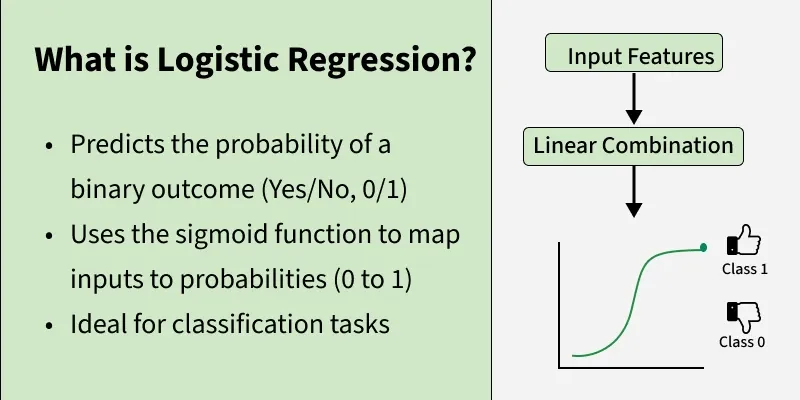

x1 x2 y
f 1  0.6
d 0  0.3
     0.2, 0.8, 0.9, 0.7


Threshold - 0.5
Yes - 0.6, 0.8, 0.9, 0.7
No - 0.2, 0.3

y = mx + b

1/1+e-y


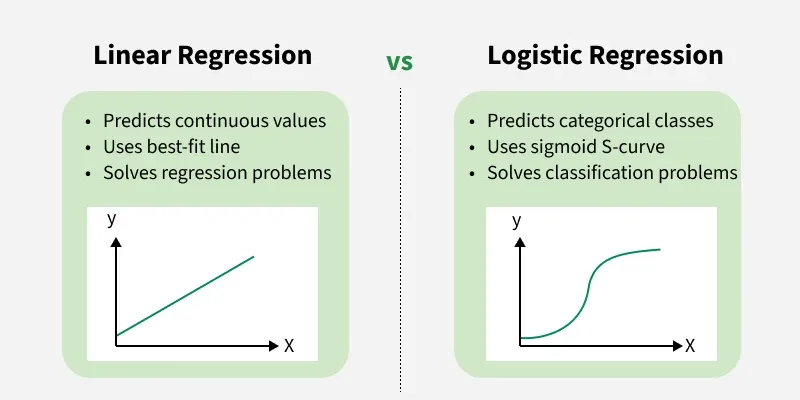

softmax - Used for multi class classification problems.

### **Types of Logistic Regression**

Logistic regression can be classified into three main types based on the nature of the dependent variable:

**Binomial Logistic Regression:** This type is used when the dependent variable has only two possible categories. Examples include Yes/No, Pass/Fail or 0/1. It is the most common form of logistic regression and is used for binary classification problems.

**Multinomial Logistic Regression:** This is used when the dependent variable has three or more possible categories that are not ordered. For example, classifying animals into categories like "cat," "dog" or "sheep." It extends the binary logistic regression to handle multiple classes.

**Ordinal Logistic Regression:** This type applies when the dependent variable has three or more categories with a natural order or ranking. Examples include ratings like "low," "medium" and "high." It takes the order of the categories into account when modeling.


**Assumptions of Logistic Regression**

**Independent observations:** Each data point is assumed to be independent of the others means there should be no correlation or dependence between the input samples.

**Binary dependent variables:** It takes the assumption that the dependent variable must be binary, means it can take only two values. For more than two categories SoftMax functions are used.

**Linearity relationship between independent variables and log odds:** The model assumes a linear relationship between the independent variables and the log odds of the dependent variable which means the predictors affect the log odds in a linear way.

**No outliers:** The dataset should not contain extreme outliers as they can distort the estimation of the logistic regression coefficients.
Large sample size: It requires a sufficiently large sample size to produce reliable and stable results.

**Understanding Sigmoid Function**

1. The sigmoid function is a important part of logistic regression which is used to convert the raw output of the model into a probability value between 0 and 1.

2. This function takes any real number and maps it into the range 0 to 1 forming an "S" shaped curve called the sigmoid curve or logistic curve. Because probabilities must lie between 0 and 1, the sigmoid function is perfect for this purpose.

3. In logistic regression, we use a threshold value usually 0.5 to decide the class label.

If the sigmoid output is same or above the threshold, the input is classified as Class 1.

If it is below the threshold, the input is classified as Class 0.

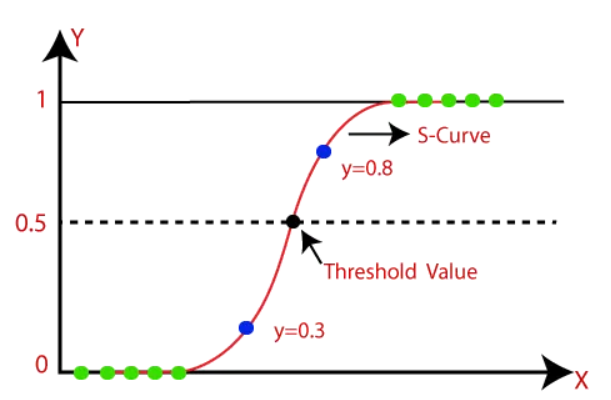

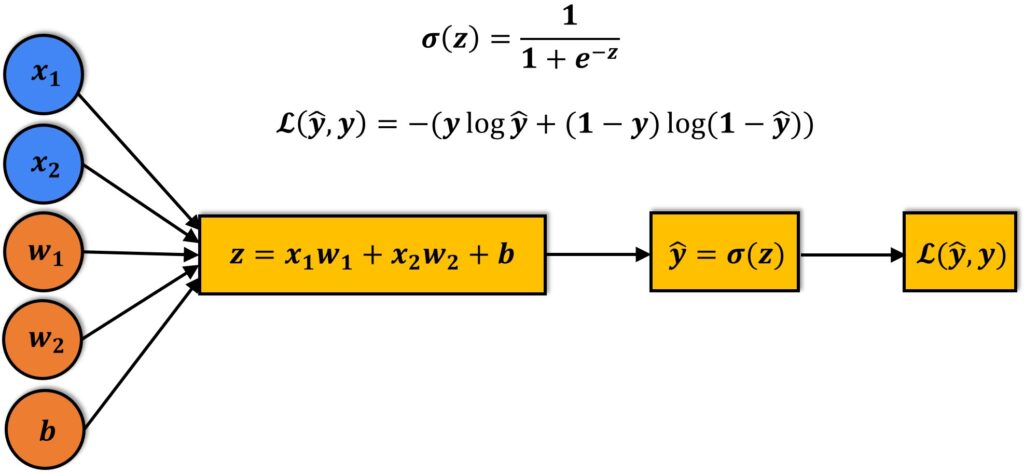

**Why is it called regression if it is a classification algorithm?**

The term “regression” in logistic regression refers to the fact that the model is trying to predict the probability of a categorical outcome, such as whether or not someone will buy a product. This is in contrast to linear regression, which is used to predict a continuous outcome, such as the price of a product.

In logistic regression, the probability of the outcome is represented by a logistic function. The logistic function is a sigmoid curve that has a range of values from 0 to 1. This means that the predicted probability of the outcome can be any value between 0 and 1.

**The hypothesis of Logistic Regression**

The hypothesis of Logistic Regression is based on the logistic function (also known as the sigmoid function). In logistic regression, we aim to model the probability of a binary outcome (e.g., 0 or 1) based on input features. The hypothesis function of logistic regression is defined as follows:

p(y = 1) = 1 / (1 + exp(-(β0 + β1x1 + β2x2)))

where:
 
   p(y = 1) is the probability of the binary outcome being equal to 1

   β0 is the intercept

   β1 and β2 are the coefficients for the predictor variables x1 and x2

   ε is the error term
   
The sigmoid function is a mathematical function that has an S-shaped curve. It is used to map the predicted values from the logistic regression model to a probability scale.

The logistic regression model is fit to the data using a maximum likelihood estimation (MLE) procedure. The MLE procedure is a statistical method that finds the parameters of a model that maximize the likelihood of the data.

Once the logistic regression model has been fit to the data, it can be used to predict the probability of a binary outcome for new data. The predicted probability is calculated as the output of the model, which is a linear combination of the predictor variables, with the sigmoid function applied to the result.

In [1]:
dataset_url = "https://raw.githubusercontent.com/harika-bonthu/02-linear-regression-fish/master/datasets_229906_491820_Fish.csv"

In [3]:
import pandas as pd
fish = pd.read_csv(dataset_url)
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [5]:
fish['Species'].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [6]:
fish.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [7]:
X = fish.iloc[:, 1:]
y = fish.loc[:, 'Species']

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
# training the model
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
y_pred = clf.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 81.25%
